In [12]:
import numpy as np

In [13]:
data_dir = './ASP'

In [14]:
# read collected data
T_asp_linear_gaps = []
T_asp_optimal_gaps = []
gaps = []
data_file = data_dir + '/scripts/data_collected'
with open(data_file,'r') as file_:
    for line in file_:
        if line.startswith('#'):
            continue
        parts = line.strip().split()
        T_asp_linear_gaps.append(float(parts[1]))
        T_asp_optimal_gaps.append(float(parts[2]))
        gaps.append(float(parts[3]))
        print(gaps[-1], T_asp_linear_gaps[-1], T_asp_optimal_gaps[-1])

0.033059539604437305 110.27570382289467 24.814502452320788
0.031433183815352095 166.15868642809164 33.57100370570505
0.04672875648975605 79.44106273640746 24.46979576743809
0.02447080045749317 167.47544237814841 37.87145490988092
0.047397264811479545 107.40798089948505 36.20837172100194
0.027227329101151554 99.29965485280104 26.512695546045617
0.04337983139430435 149.62477440394863 37.91316297300594
0.04632897637839051 107.12945256213767 37.14905147387266
0.0387093949238988 295.3895860240303 71.42113303621383
0.03970427634885709 213.0260319157219 59.571290065480646
0.013778555437056639 1109.8347321796734 105.9685937609086
0.00027324981329002185 658668.3091952007 37583.403127943675
0.02529333772827158 239.7787043725563 53.43280625921115
0.03439862668619753 187.58898109032845 57.62071261278292
0.01885532756568864 1354.7613986223164 142.0760759289062
0.030008703363819222 382.9449155669398 88.5792691005765
0.0003620480856625363 1397081.3783969542 17534.56087209685
0.008848920379023184 4498

In [15]:
# read LK data
L_for_gaps = []
K_for_gaps = []
gaps_for_LK = []
data_file = data_dir + '/scripts/LK_collected'
with open(data_file,'r') as file_:
    for line in file_:
        if line.startswith('#'):
            continue
        parts = line.strip().split()
        gaps_for_LK.append(float(parts[0]))
        L_for_gaps.append(float(parts[1]))
        K_for_gaps.append(float(parts[2]))
        print(gaps_for_LK[-1],L_for_gaps[-1],K_for_gaps[-1])
# sort for better plot

gaps_for_LK = np.array(gaps_for_LK)
L_for_gaps = np.array(L_for_gaps)
K_for_gaps = np.array(K_for_gaps)

sort_indices = np.argsort(gaps_for_LK)
gaps_for_LK = gaps_for_LK[sort_indices]
L_for_gaps = L_for_gaps[sort_indices]
K_for_gaps = K_for_gaps[sort_indices]

0.033059539604437305 1.9308215444784194 3.416972992224263
0.031433183815352095 2.0569526798523463 3.8009319033721387
0.04672875648975605 2.131650665356126 3.8281916918853516
0.02447080045749317 2.258186302576867 4.175662786553251
0.047397264811479545 2.4094171360047953 4.257001967009373
0.027227329101151554 2.320345952284988 4.333235476348418
0.04337983139430435 2.393679608873253 4.355118456474531
0.04632897637839051 2.567579728070013 4.625621160540622
0.0387093949238988 2.7760251120269954 5.115813416098991
0.03970427634885709 2.7524352602298903 4.980874963531423
0.013778555437056639 2.4126649609114796 4.71711299855455
0.00027324981329002185 3.991228591466315 10.832793666488774
0.02529333772827158 3.047045773409432 5.8246283398402525
0.03439862668619753 3.0235002660779933 5.5555078976585355
0.01885532756568864 2.645446575917614 4.968794167745354
0.030008703363819222 3.111839965257606 5.68894699711185
0.0003620480856625363 6.180392526231411 10.947797218738305
0.008848920379023184 3.2649

In [16]:
costs = [4/gap for gap in gaps]
T_asp_optimal_plus_costs = [T_asp_optimal_gaps[i] + costs[i] for i in range(len(gaps))]


In [17]:
# read data
import re
number_pattern = re.compile(r"""
    [+-]?                           # optional sign
    (?:\d+\.\d*|\.\d+|\d+)          # decimal or integer
    (?:[eE][+-]?\d+)?               # optional exponent
""", re.VERBOSE)
#data_index = 97
data_index = 3563
case_dir = data_dir + '/data/' + str(data_index)
# find position
with open(case_dir + '/gap_min_finding/log_0', 'r') as file_:
    lines = file_.readlines()
    for line in lines:
        if (line.startswith('# with the gap minimum value')):
            raw_nums = number_pattern.findall(line)
            gap = float(raw_nums[0])
for ind in range(len(gaps)):
    if (np.abs(gaps[ind]-gap)<1e-10):
        print('gap_est_min found at index:', ind)
        mark = ind
        print(gaps[mark], T_asp_linear_gaps[mark], T_asp_optimal_gaps[mark])
        break
print(mark)
asp_schedule_dir = case_dir + '/on_the_fly/'
asp_optimal_dir = case_dir + '/asp/optimal'
asp_linear_dir = case_dir + '/asp/linear'
t_list = []
s_list = []
with open(asp_schedule_dir + '/optimal_schedule','r') as file_:
    for line in file_:
        if not line.strip():
            continue
        if line.startswith('#'):
            continue
        ls = line.split()
        t_list.append(float(ls[0]))
        s_list.append(float(ls[1]))
        #print(ls[0], ls[1])

#print('--')
    
tf_grid_optimal = []
fidelity_optimal = []
tf_grid_linear = []
fidelity_linear = []

with open(asp_optimal_dir + '/fidelity','r') as file_:
    for line in file_:
        if not line.strip():
            continue
        if line.startswith('#'):
            continue
        ls = line.split()
        tf_grid_optimal.append(float(ls[0]))
        fidelity_optimal.append(float(ls[1]))
        print(ls[0], ls[1])

print('--')
with open(asp_linear_dir + '/fidelity','r') as file_:
    for line in file_:
        if not line.strip():
            continue
        if line.startswith('#'):
            continue
        ls = line.split()
        tf_grid_linear.append(float(ls[0]))
        fidelity_linear.append(float(ls[1]))
        print(ls[0], ls[1])

gap_est_min found at index: 33
0.00047005818123579957 2407415.7964448105 6647.1513844023875
33
1.0000000000000000e+00 3.5991062636040040e-05
2.0000000000000000e+00 3.9770194489707048e-05
3.0000000000000000e+00 4.2583016854082436e-05
5.0000000000000000e+00 4.9383316366464179e-05
8.0000000000000000e+00 6.8897862928170625e-05
1.4000000000000000e+01 1.2704378374822972e-04
2.3000000000000000e+01 3.0563772920013277e-04
4.0000000000000000e+01 7.9541868389085963e-04
6.7000000000000000e+01 1.4111884730192434e-03
1.1400000000000000e+02 1.2223649474188305e-03
1.9200000000000000e+02 1.1679677715957409e-03
3.2500000000000000e+02 1.4161197897763511e-03
5.5100000000000000e+02 5.1069177957785861e-03
9.3200000000000000e+02 1.5683642643989346e-02
1.5760000000000000e+03 4.4034576636386866e-02
2.6670000000000000e+03 1.1652697386377471e-01
4.5130000000000000e+03 2.9239172131331831e-01
7.6360000000000000e+03 6.3562731952165274e-01
1.2920000000000000e+04 9.6371740842909315e-01
2.1861000000000000e+04 9.808783

In [18]:
# find 75% fidelity time
from scipy.interpolate import interp1d
fidelity_linear_fct = interp1d(tf_grid_linear, fidelity_linear)
fidelity_optimal_fct = interp1d(tf_grid_optimal, fidelity_optimal)

from scipy.optimize import brentq

t_75_linear = brentq(lambda x: fidelity_linear_fct(x) - 0.75, tf_grid_linear[0], tf_grid_linear[-1])
print(t_75_linear)

t_75_optimal = brentq(lambda x: fidelity_optimal_fct(x) - 0.75, tf_grid_optimal[0], tf_grid_optimal[-1])
print(t_75_optimal)

print(t_75_linear/t_75_optimal)

2737564.2715363833
9478.010057847503
288.83323132472975


In [19]:
from scipy.optimize import curve_fit
def func(x, r, c):
    return c/x**r
f_1 = lambda x, c : func(x, 1, c)
f_2 = lambda x, c : func(x, 2, c)



optimal_fit, _ = curve_fit(f_1, gaps, T_asp_optimal_gaps, p0=np.pi/2)
cost_fit, _ = curve_fit(f_1, gaps, T_asp_optimal_plus_costs, p0=np.pi/2)
linear_fit, _ = curve_fit(f_2, gaps, T_asp_linear_gaps, p0=np.pi/2)

print(*optimal_fit, *linear_fit, *cost_fit, sep=', ')

6.204189974234406, 0.13759629350248792, 10.204189936368058


In [20]:
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection
from matplotlib.colors import LogNorm

def draw_gradient_circle(ax, center, radius, cmap, name,
                         vmin=0.01, num_layers=100, text_offset=1.3, y_offset=0.0, **text_kwargs):
    """
    Draw a full radial gradient circle inside an inset axes.

    - ax: inset axes
    - center: (x, y) center in data coords of inset [0,1]×[0,1]
    - radius: radius in same units (e.g. 0.4 for 40% of box)
    - cmap: colormap name
    - name: label text (without colon)
    """
    # Create concentric circle patches
    radii = np.linspace(radius, 0, num_layers)
    patches = [Circle(center, r) for r in radii]
    
    # Build PatchCollection and disable clipping
    norm = LogNorm(vmin=vmin, vmax=radius)
    coll = PatchCollection(patches, array=radii, cmap=cmap, norm=norm, edgecolor='none')
    ax.add_collection(coll)
    
    
    # Set the view limits to exactly the circle bounding box
    x0, y0 = center
    ax.set_xlim(x0 - radius, x0 + radius)
    ax.set_ylim(y0 - radius, y0 + radius)
    ax.set_aspect('equal', 'box')
    ax.axis('off')
    
    # Label just outside the circle
    tx = x0 + radius * text_offset
    ty = y0 + y_offset
    ax.text(tx, ty, name, va='center', ha='left', **text_kwargs)

from matplotlib.colors import LinearSegmentedColormap

# 1) Build a colormap restricted to yellow tones
yellow_list = [
    (1.0, 1.0, 0.533),  # near-white pale yellow
    (0.965, 0.945, 0.039),
    (0.749, 0.733, 0.0),  # mustard yellow
]
yellow_cmap = LinearSegmentedColormap.from_list("pure_yellow", yellow_list)

/tmp/ipykernel_27109/1688726478.py:303: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


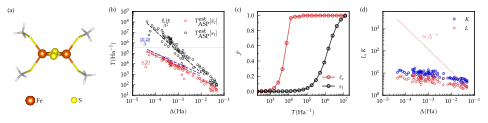

In [21]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.patheffects as patheffects
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator
import matplotlib.image as mpimg
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size"  : 6
})

# Figure size: 2 columns × width_col, height = width_col/2 (in inches)
cm        = 1.0 / 2.54
width_col = 8.6 * cm
width     = width_col * 2
height    = width_col / 2
#plt.figure(figsize=(width,height),dpi=600)

# Create figure and 4 horizontal panels with default padding
fig, axes = plt.subplots(1, 4, figsize=(width, height),dpi=600)

# Work in panel (a)
# exact schedule

marker_style_ref = dict(marker='',linestyle='dotted',color='gray',alpha=0.9,linewidth=0.4)

marker_style_1   = dict(marker='o', markersize=3, linestyle='solid', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_1_p4   = dict(marker='o', markersize=3, linestyle='', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_1_sm   = dict(marker='o', markersize=3, linestyle='solid', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_1_p   = dict(marker='o', markersize=2, linestyle='', color='tab:red', alpha=0.8,  fillstyle='none',mew=0.5)
marker_style_1_mark   = dict(marker='x', markersize=3.0, linestyle='', color='tab:red', alpha=1.0,  fillstyle='full',mew=0.7)
marker_style_1_l   = dict(marker='', linestyle='solid', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_1_ref = dict(marker='',linestyle='dashed',color='tab:red',alpha=0.8,linewidth=0.8)
marker_style_1_ref_2 = dict(marker='',linestyle='dashed',color='tab:red',alpha=0.6,linewidth=0.5)

marker_style_2   = dict(marker='o', markersize=3, linestyle='solid', color='black', alpha=0.8,  fillstyle='none')
marker_style_2_sm   = dict(marker='o', markersize=3, linestyle='solid', color='black', alpha=0.8,  fillstyle='none')
marker_style_2_p   = dict(marker='o', markersize=2, linestyle='', color='black', alpha=0.8,  fillstyle='none',mew=0.5)
marker_style_2_mark   = dict(marker='x', markersize=3.0, linestyle='', color='black', alpha=1.0,  fillstyle='full',mew=0.7)
marker_style_2_l   = dict(marker='', linestyle='solid', color='black', alpha=0.8,  fillstyle='none')
marker_style_2_ref = dict(marker='',linestyle='dashed',color='black',alpha=0.8,linewidth=0.8)

marker_style_3   = dict(marker='o', markersize=3, linestyle='solid', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_sm   = dict(marker='o', markersize=3, linestyle='solid', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_p   = dict(marker='o', markersize=2, linestyle='', color='mediumblue', alpha=0.6,  fillstyle='none')
marker_style_3_l   = dict(marker='', linestyle='solid', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_ref   = dict(marker='', linestyle='dashed', color='mediumblue', alpha=0.8, linewidth=0.8)


img = mpimg.imread('Fe2S2.png')
axis = axes[0]
axis.text(0, 1.10, r'(a)',transform=axis.transAxes)
y0, y1 = 500, 2000
x0, x1 = 1500, 3500
roi = img[y0:y1, x0:x1]
#axis.text(0.35,0.46, r'Fe',transform=axis.transAxes, color='black')
axis.imshow(roi)
axis.margins(0)
axis.axis('off')          # Hide ticks and axes
inset_fe = inset_axes(
    axis,
    width="37%", height="37%",
    bbox_to_anchor=(0.15, -0.3, 0.37, 0.37),    # Lower-left corner of the inset (relative to axis)
    bbox_transform=axis.transAxes,
    loc='lower left'
)
inset_fe.axis('off')

# Center at (0.5, 0.5), radius 0.4
draw_gradient_circle(
    inset_fe,
    center=(0.5, 0.5),    # center in inset coordinates
    radius=0.4,           # 40% of the inset size
    vmin=0.05,
    cmap='Oranges',
    y_offset = -0.05,
    name='Fe',
    fontsize=6
)

inset_S = inset_axes(
    axis,
    width="30%", height="30%",
    bbox_to_anchor=(0.65, -0.27, 0.30, 0.30),    # Lower-left corner of the inset (relative to axis)
    bbox_transform=axis.transAxes,
    loc='lower left'
)
inset_S.axis('off')

# Center at (0.5, 0.5), radius 0.4
draw_gradient_circle(
    inset_S,
    center=(0.5, 0.5),    # center in inset coordinates
    radius=0.2,           # 40% of the inset size
    vmin=0.05,
    cmap=yellow_cmap,
    text_offset=1.5,
    y_offset = -0.05,
    name='S',
    fontsize=6
)
#axis.set_aspect('equal')  # fix aspect ratio

# Work in panel (d) - T_asp vs gap
axis = axes[1]

t_qpe = 379913.5302015563

y_min    =  10
y_max    =  10**9

x_min    =  1e-5
x_max    =  0.1


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.26, 1, r'(b)',transform=axis.transAxes)
axis.set_xlabel(r'$\Delta (\textrm{Ha})$')
axis.set_ylabel(r'$T(\textrm{Ha}^{-1})$')
# setup tics
axis.tick_params(axis='x', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='x', which='minor', direction='in', length=1.4, width=0.4)
axis.tick_params(axis='y', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='y', which='minor', direction='in', length=1.4, width=0.4)
#axis.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
#axis.xaxis.set_major_formatter('{x:0.1f}')
#axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
axis.set_xscale('log')
axis.set_yscale('log')

axis.yaxis.set_major_locator(LogLocator(base=10.0, numticks=12))
axis.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=12))


#axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
#axis.yaxis.set_major_formatter('{x:3.1f}')
#axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# QPE line

axis.axhline(y=t_qpe, label='', **marker_style_ref)


axis.plot(gaps,T_asp_optimal_gaps, 
          label =r'$T_\textrm{ASP}^{\textrm{est}}[\hat{s}_c]$', **marker_style_1_p)

#axis.plot(gaps,T_asp_optimal_plus_costs, label =r'$T_{\textrm{total}}[\hat{s}_c]$', **marker_style_3_p)
axis.plot(gaps[mark],T_asp_optimal_gaps[mark],label='', **marker_style_1_mark)

axis.plot(gaps,T_asp_linear_gaps, 
          label =r'$T_\textrm{ASP}^{\textrm{est}}[s_l]$', **marker_style_2_p)

axis.plot(gaps[mark],T_asp_linear_gaps[mark],label='', **marker_style_2_mark)


# fitting curves

gaps_coarse = np.linspace(min(gaps),10**(-2),5)
axis.plot(gaps_coarse,[optimal_fit[0]/x for x in gaps_coarse], label =r'', **marker_style_1_ref)
val = optimal_fit[0]
val_formatted = f"{val:.2f}"
formatted = rf"$\frac{{{val_formatted}}}{{\Delta}}$"
axis.text(0.10, 0.35, formatted,transform=axis.transAxes, color='tab:red')

axis.plot(gaps_coarse,[cost_fit[0]/x for x in gaps_coarse], 
          label ='', **marker_style_3_ref)
val = cost_fit[0]
val_formatted = f"{val:.2f}"
formatted = rf"$\frac{{{val_formatted}}}{{\Delta}}$"
axis.text(0.08, 0.62, formatted,transform=axis.transAxes, color='mediumblue')

axis.plot(gaps_coarse,[linear_fit[0]/x**2 for x in gaps_coarse], label ='', **marker_style_2_ref)

val = linear_fit[0]
val_formatted = f"{val:.2f}"
formatted = rf"$\frac{{{val_formatted}}}{{\Delta^2}}$"
axis.text(0.32, 0.85, formatted,transform=axis.transAxes, color='black')

axis.legend(loc='upper right',handlelength=1.5,frameon=False)




# secondary axis
# bad visual

# s_fine = np.linspace(0, 1, 101)
# e0_fine = 0.5 * (1-gap_grover(s_fine))
# e1_fine = 0.5 * (1+gap_grover(s_fine))
# 
# ax2 = axis.twiny()
# ax2.plot(e0_fine, s_fine, label ='', **marker_style_ref)
# ax2.plot(e1_fine, s_fine, label ='', **marker_style_ref)
# ax2.set_xlabel(r'$E(s)$')

# Work in panel (c) - fidelity
axis = axes[2]


x_min    =  2e2
x_max    =  2e7

y_min    =  -0.05
y_max    =  +1.05


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
#axis.text(0.15, 0.5, r'$R=3.0\AA$',transform=axis.transAxes,color='gray')
axis.text(-0.25, 1, r'(c)',transform=axis.transAxes)
axis.set_xlabel(r'$T(\textrm{Ha}^{-1})$')
axis.set_ylabel(r'$\mathcal{F}$')
# setup tics
axis.tick_params(axis='x', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='x', which='minor', direction='in', length=1.4, width=0.4)
axis.tick_params(axis='y', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='y', which='minor', direction='in', length=1.4, width=0.4)
#axis.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
#axis.xaxis.set_major_formatter('{x:0.1f}')
#axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
axis.set_xscale('log')

axis.xaxis.set_major_locator(LogLocator(base=10.0, numticks=6))


axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:3.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

axis.plot(tf_grid_optimal,fidelity_optimal, label =r'$\hat{s}_c$', lw=0.8, **marker_style_1_sm)
axis.plot(tf_grid_linear,fidelity_linear, label =r'$s_l$', lw=0.8, **marker_style_2_sm)

axis.legend(loc='lower right',frameon=False)


axis = axes[3]

x_min    =  1e-5
x_max    =  0.1

y_min    =  1.0
y_max    =  6000


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.25, 1, r'(d)',transform=axis.transAxes)
axis.set_xlabel(r'$\Delta(\textrm{Ha})$')
axis.set_ylabel(r'$L,K$')
# setup tics
axis.tick_params(axis='x', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='x', which='minor', direction='in', length=1.4, width=0.4)
axis.tick_params(axis='y', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='y', which='minor', direction='in', length=1.4, width=0.4)
#axis.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
#axis.xaxis.set_major_formatter('{x:0.1f}')
#axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
axis.set_xscale('log')
axis.set_yscale('log')

axis.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
axis.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=12))

axis.xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
axis.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=12))


#axis.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
#axis.yaxis.set_major_formatter('{x:3.1f}')

axis.plot(gaps_for_LK, K_for_gaps, label =r'$K$', lw=0.8, **marker_style_3_p)
axis.plot(gaps_for_LK, L_for_gaps, lw=0.8, label ='$L$', **marker_style_1_p)
axis.plot(gaps_for_LK, L_for_gaps[-1]*gaps_for_LK[-1]/gaps_for_LK, label ='', **marker_style_1_ref_2)
#axis.plot(gaps_for_LK, K_for_gaps[-1]*gaps_for_LK[-1]/(gaps_for_LK), label ='', **marker_style_3_ref)

#val = path_lengths[0]*gaps_for_kappas[0]
#val_formatted = f"{val:.2f}"
#formatted = rf"$\frac{{{val_formatted}}}{{\Delta}}$"
ss =  r'$\propto \Delta^{-1}$'
axis.text(0.43, 0.68,ss,transform=axis.transAxes, color='tab:red', alpha=0.6)

#val = kappas[0]*gaps_for_kappas[0]
#val_formatted = f"{val:.2f}"
#formatted = rf"$\frac{{{val_formatted}}}{{\Delta}}$"
#ss =  r'$\propto \Delta^{-2}/L$'
#axis.text(0.25, 0.85, ss,transform=axis.transAxes, color='mediumblue',alpha=0.6)

axis.legend(loc='upper right',frameon=False)






plt.tight_layout()
plt.savefig('fig4.pdf')